In [6]:
import numpy as np
import matplotlib.pyplot as plt
import strawberryfields as sf
from strawberryfields.ops import Sgate, Dgate, BSgate, Vac
from numpy.polynomial.hermite import hermgauss
from scipy.special import eval_hermite, factorial

In [11]:
def alice_encode(raw_key_len, V_a):

    a_x = np.random.normal(loc=0, scale=np.sqrt(V_a), size=raw_key_len)
    a_p = np.random.normal(loc=0, scale=np.sqrt(V_a), size=raw_key_len)

    return a_x, a_p

In [95]:
def bob_measure(a_x, a_p, raw_key_len, eta):

    choices = np.random.randint(0, 2, size=raw_key_len)
    measurements = np.zeros(raw_key_len)

    for i, choice in enumerate(choices):

        if choice==0:
            measurements[i] = np.random.normal(loc=np.sqrt(eta)*a_x[i], scale=1)

        elif choice==1:
            measurements[i] = np.random.normal(loc=np.sqrt(eta)*a_p[i], scale=1)

    return measurements, choices

In [ ]:
def alice_align(bob_choices, a_x, a_p):

    measurements = np.zeros(bob_choices.size)
    for i, choice in enumerate(bob_choices):

        if choice==0:
            measurements[i] = a_x[i]
            
        elif choice==1:
            measurements[i] = a_p[i]

    return measurements

In [ ]:
def mutual_information(alice_measurements:np.array, bob_measurements:np.array):

    rho = np.corrcoef(alice_measurements, bob_measurements)[0, 1]

    return -0.5*np.log2(1 - rho**2)

In [98]:
raw_key_len = 1000
eta = 0.3
sigma_grid = np.linspace(0, 100, 1001)
I = np.zeros(sigma_grid.size)

for i, sigma in enumerate(sigma_grid):

    a_x, a_p = alice_encode(raw_key_len=raw_key_len, V_a = sigma**2)
    bob_measurements, bob_choices = bob_measure(a_x, a_p, raw_key_len=raw_key_len, eta=eta)
    alice_measurements = alice_align(bob_choices, a_x, a_p)

    I[i] = mutual_information(alice_measurements, bob_measurements)

In [103]:
def I_theory(sigma_x, eta, V):

    I = 0.5*np.log2(1 + (sigma_x**2*eta)/(1 + eta*(V - 1)))
    return I

sigma_x = np.linspace(0, 100, 1001)

I_theory = np.array([I_theory(val, 0.3, 1) for val in sigma_x])



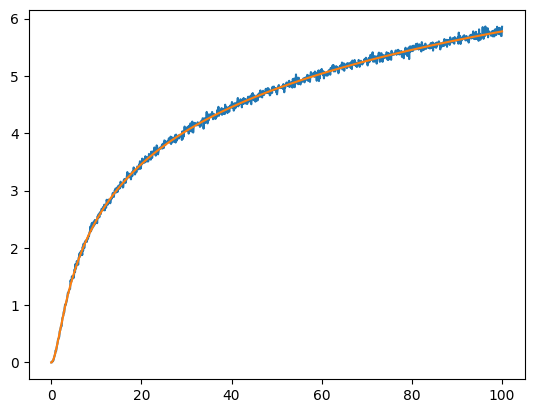

In [104]:
plt.plot(sigma_grid, I)
plt.plot(sigma_x, I_theory)